In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [4]:
df = pd.read_csv("mall_customers.csv")

In [5]:
df.head

<bound method NDFrame.head of      customer_id  gender  age  annual_income  spending_score
0              1    Male   19             15              39
1              2    Male   21             15              81
2              3  Female   20             16               6
3              4  Female   23             16              77
4              5  Female   31             17              40
..           ...     ...  ...            ...             ...
195          196  Female   35            120              79
196          197  Female   45            126              28
197          198    Male   32            126              74
198          199    Male   32            137              18
199          200    Male   30            137              83

[200 rows x 5 columns]>

In [7]:
df.isnull().sum()

customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

In [10]:
print(df .columns)

Index(['customer_id', 'gender', 'age', 'annual_income', 'spending_score'], dtype='str')


In [11]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['customer_id', 'gender', 'age', 'annual_income', 'spending_score'], dtype='str')


In [13]:
X = df[["annual_income", "spending_score"]]

In [14]:
X

,annual_income,spending_score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
model = DBSCAN(eps=0.3, min_samples=5)

model.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](138, 2)","[[-1.74, 1.2 ], [-1.7 , 1.04], [-1.66, 1. ], ..., [ 1.05,-1.37], [ 1.24,-1.41], [ 1.24, 1.55]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](138,)","[ 1, 3, 5,...,176,178,179]"


In [17]:
labels = model.labels_

print(labels)

[ 2  0  1  0  2  0  1 -1  1  0 -1 -1 -1  0  1  0  2  0  2 -1  2  0  1  0
 -1 -1  2 -1  2 -1 -1  0 -1 -1 -1 -1 -1  0 -1  0  3 -1  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  4  3  4  3  4  5  4  5  4  3  4  5  4  5  4  5  4  5  4  3  4
  5  4  3  4  5  4  5  4  5  4  5  4  5  4  5  4  3  4  5  4  6  4  6  4
  6 -1  6  4  6  4  6  4  6  4  6  4 -1  4  6  4 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


In [18]:
df["cluster"] = labels

print(df.head())

   customer_id  gender  age  annual_income  spending_score  cluster
0            1    Male   19             15              39        2
1            2    Male   21             15              81        0
2            3  Female   20             16               6        1
3            4  Female   23             16              77        0
4            5  Female   31             17              40        2


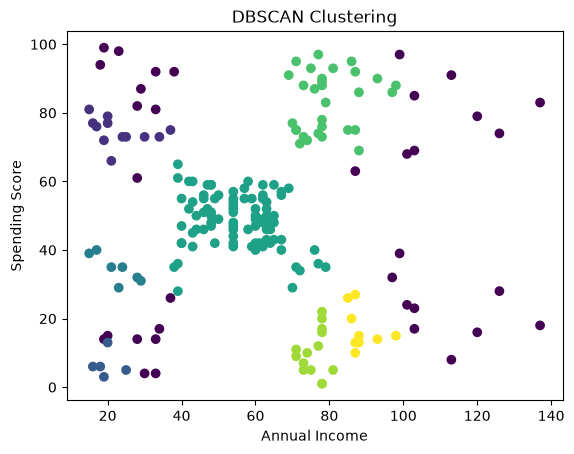

In [19]:
import matplotlib.pyplot as plt

plt.scatter(
    X["annual_income"],
    X["spending_score"],
    c=labels
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")

plt.show()

In [20]:
print(df["cluster"].value_counts())

cluster
 3    88
-1    35
 4    30
 5    14
 0    12
 6     9
 2     7
 1     5
Name: count, dtype: int64
